# NB12c — F-B (correct): visualize the faithfulness METRIC per-region

The deletion-curve version failed (saturation reappears in any absolute-score plot). This figure
shows the ACTUAL saturation-free metric: per Grad-CAM region, importance (x) vs actual prob_fake
effect when that region is removed (y). The rank correlation between them IS the faithfulness
metric (the r=+0.94 result).

- Competent detector (faithful): high-importance regions have large effect -> points rise ->
  positive Spearman.
- Incompetent detector (unfaithful): importance and effect uncorrelated -> points scatter ->
  near-zero Spearman.

Saturation-robust by construction: it's the RANK agreement of importance vs effect per region,
never the absolute score. Aggregated over ~12 frames/generator for a dense, clean scatter.


## Cell 1 — Load model

In [1]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)
import os, sys, glob, subprocess, importlib.util
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
DFB = f"{REPO}/external/DeepfakeBench"
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"): subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git config --global credential.helper store", shell=True)
subprocess.run("pip -q install efficientnet_pytorch timm einops kornia simplejson", shell=True)
for k in list(sys.modules.keys()):
    if k.startswith("detectors") or k.startswith("networks") or k=="metrics" or k.startswith("metrics.") or k=="inference":
        del sys.modules[k]
sys.path=[p for p in sys.path if p not in (f"{DFB}/training",f"{REPO}/src",DFB)]
sys.path.insert(0,DFB);sys.path.insert(0,f"{DFB}/training");sys.path.append(f"{REPO}/src")
spec=importlib.util.spec_from_file_location("inference",f"{REPO}/src/inference.py")
inference=importlib.util.module_from_spec(spec);sys.modules["inference"]=inference
spec.loader.exec_module(inference)
model,device,info=inference.load_detector(dfb_root=DFB,backbone_name="xception",ckpt_path=f"{REPO}/weights/train_on_fs/xception.pth")
model.eval();print("loaded",info)

Mounted at /content/drive
loaded {'missing': 0, 'unexpected': 0}


## Cell 2 — Grad-CAM + per-region (importance, effect) extraction

In [2]:
import torch, numpy as np, cv2
import torch.nn.functional as F
MEAN=torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)
STD=torch.tensor([0.5,0.5,0.5]).view(1,3,1,1).to(device)
def load_img(p):
    im=cv2.imread(p)[:,:,::-1];im=cv2.resize(im,(256,256));return im.astype(np.float32)/255.0
def to_tensor(im):return (torch.from_numpy(im).permute(2,0,1).unsqueeze(0).to(device)-MEAN)/STD
target=dict(model.backbone.named_modules())['conv4']
def grad_cam(im):
    acts={};grads={}
    h1=target.register_forward_hook(lambda m,i,o:acts.__setitem__('a',o))
    h2=target.register_full_backward_hook(lambda m,gi,go:grads.__setitem__('g',go[0]))
    x=to_tensor(im).requires_grad_(True);out=model({'image':x},inference=False)
    model.zero_grad();out['cls'][0,1].backward()
    A=acts['a'][0];G=grads['g'][0];w=G.mean(dim=(1,2))
    cam=F.relu((w.view(-1,1,1)*A).sum(0));cam=cam-cam.min();cam=cam/(cam.max()+1e-8)
    cam=F.interpolate(cam.view(1,1,8,8),size=(256,256),mode='bilinear',align_corners=False)[0,0]
    h1.remove();h2.remove();return cam.detach().cpu().numpy()
@torch.no_grad()
def prob_fake_of(im):
    out=model({'image':to_tensor(im)},inference=True)
    return float(out['prob']) if out['prob'].dim()==0 else float(out['prob'][0])
def region_importance_effect(im, cam, grid=8):
    H,W=cam.shape;ph,pw=H//grid,W//grid
    blurred=cv2.GaussianBlur(im,(0,0),sigmaX=11);base=prob_fake_of(im)
    imp=[];eff=[]
    for gy in range(grid):
        for gx in range(grid):
            y0,y1=gy*ph,(gy+1)*ph;x0,x1=gx*pw,(gx+1)*pw
            imp.append(float(cam[y0:y1,x0:x1].mean()))
            tmp=im.copy();tmp[y0:y1,x0:x1,:]=blurred[y0:y1,x0:x1,:]
            eff.append(base-prob_fake_of(tmp))
    return np.array(imp),np.array(eff)
print("ready")

ready


## Cell 3 — Collect per-region pairs across frames for 4 detectors

In [3]:
import os, glob, zipfile, shutil, pickle
import pandas as pd, numpy as np
from scipy.stats import spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
SHORTCUT="/content/drive/MyDrive/CDTS_Research/DF40";LOCALCORE=f"{REPO}/data/df40_core/test"
PANEL=[("simswap","high",0.948),("blendface","high",0.943),("pixart","low",0.433),("sadtalker","low",0.427)]
NFRAMES=12
def get_zip(m):
    for c in [f"{LOCALCORE}/{m}.zip",f"{SHORTCUT}/{m}.zip"]:
        if os.path.exists(c) and os.path.getsize(c)>1e6:return c
    return None
results={}
for method,comp,auc in PANEL:
    zp=get_zip(method)
    if not zp:print(f"{method}: no zip");continue
    fdir=f"/content/fc_{method}";os.makedirs(fdir,exist_ok=True)
    try:
        with zipfile.ZipFile(zp) as z:z.extractall(fdir)
    except:print(f"{method}: unzip fail");shutil.rmtree(fdir,ignore_errors=True);continue
    pngs=sorted(glob.glob(f"{fdir}/**/*.png",recursive=True))[:NFRAMES*3]
    all_imp=[];all_eff=[];per_frame_rho=[];done=0
    for fp in pngs:
        try:
            im=load_img(fp);cam=grad_cam(im);imp,eff=region_importance_effect(im,cam,grid=8)
            if imp.std()<1e-6 or eff.std()<1e-6: continue
            all_imp.append(imp);all_eff.append(eff)
            per_frame_rho.append(spearmanr(imp,eff).statistic);done+=1
            if done>=NFRAMES:break
        except: continue
    shutil.rmtree(fdir,ignore_errors=True)
    if all_imp:
        results[method]={'comp':comp,'auc':auc,
                         'imp':np.concatenate(all_imp),'eff':np.concatenate(all_eff),
                         'mean_rho':float(np.mean(per_frame_rho)),'n':done}
        print(f"{method}: mean per-frame faithfulness(rho)={np.mean(per_frame_rho):.3f} (n={done} frames)")
pickle.dump(results,open("/content/fc_results.pkl","wb"))
print("saved")

simswap: mean per-frame faithfulness(rho)=0.725 (n=12 frames)
blendface: mean per-frame faithfulness(rho)=0.705 (n=12 frames)
pixart: mean per-frame faithfulness(rho)=0.132 (n=12 frames)
sadtalker: mean per-frame faithfulness(rho)=0.492 (n=12 frames)
saved


In [3]:
import os, glob, zipfile, shutil, pickle
import pandas as pd, numpy as np
from scipy.stats import spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
SHORTCUT="/content/drive/MyDrive/CDTS_Research/DF40";LOCALCORE=f"{REPO}/data/df40_core/test"
# swapped sadtalker -> wav2lip (most reliably unfaithful, full-data rho~0.11)
PANEL=[("simswap","high",0.948),("blendface","high",0.943),("pixart","low",0.433),("wav2lip","low",0.470)]
NFRAMES=15  # bumped slightly for stability
def get_zip(m):
    for c in [f"{LOCALCORE}/{m}.zip",f"{SHORTCUT}/{m}.zip"]:
        if os.path.exists(c) and os.path.getsize(c)>1e6:return c
    return None
results={}
for method,comp,auc in PANEL:
    zp=get_zip(method)
    if not zp:print(f"{method}: no zip");continue
    fdir=f"/content/fc_{method}";os.makedirs(fdir,exist_ok=True)
    try:
        with zipfile.ZipFile(zp) as z:z.extractall(fdir)
    except:print(f"{method}: unzip fail");shutil.rmtree(fdir,ignore_errors=True);continue
    pngs=sorted(glob.glob(f"{fdir}/**/*.png",recursive=True))[:NFRAMES*3]
    all_imp=[];all_eff=[];per_frame_rho=[];done=0
    for fp in pngs:
        try:
            im=load_img(fp);cam=grad_cam(im);imp,eff=region_importance_effect(im,cam,grid=8)
            if imp.std()<1e-6 or eff.std()<1e-6: continue
            all_imp.append(imp);all_eff.append(eff)
            per_frame_rho.append(spearmanr(imp,eff).statistic);done+=1
            if done>=NFRAMES:break
        except: continue
    shutil.rmtree(fdir,ignore_errors=True)
    if all_imp:
        results[method]={'comp':comp,'auc':auc,
                         'imp':np.concatenate(all_imp),'eff':np.concatenate(all_eff),
                         'mean_rho':float(np.mean(per_frame_rho)),'n':done}
        print(f"{method}: mean per-frame faithfulness(rho)={np.mean(per_frame_rho):.3f} (n={done} frames)")
pickle.dump(results,open("/content/fc_results.pkl","wb"))
print("saved")

simswap: mean per-frame faithfulness(rho)=0.725 (n=15 frames)
blendface: mean per-frame faithfulness(rho)=0.704 (n=15 frames)
pixart: mean per-frame faithfulness(rho)=0.166 (n=15 frames)
wav2lip: mean per-frame faithfulness(rho)=-0.045 (n=15 frames)
saved


## Cell 4 — Build the figure (importance vs effect scatter per detector) + commit

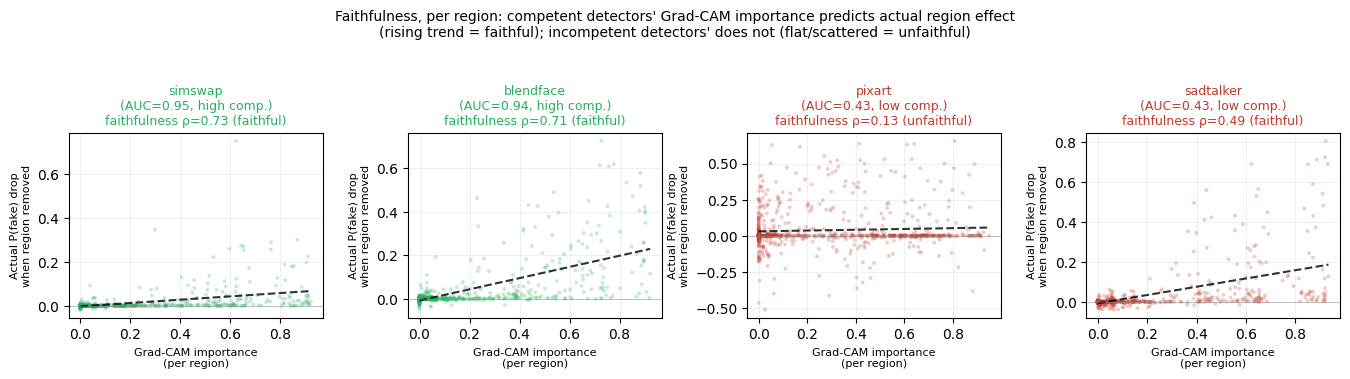

saved /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/gradcam_faithfulness_perregion.png
 m external/DeepfakeBench
A  figures/gradcam_faithfulness_demonstrated.png
A  figures/gradcam_faithfulness_perregion.png
A  figures/gradcam_qualitative.png
A  figures/reliability_diagrams.png
A  figures/subgroup_calibration.png
A  figures/trust_signal_heatmap.png
 M notebooks/NB06_effnet_df40.ipynb
 M notebooks/NB08_timeline_scoring.ipynb
 M notebooks/NB09_labelfree_competence.ipynb
 M notebooks/NB10b_explanation_rankcorr.ipynb
 M notebooks/NB11_zero_trust_routing.ipynb
AM notebooks/NB12_paper_figures.ipynb
AM notebooks/NB12b_gradcam_faithfulness.ipynb
A  notebooks/NB12c_faithfulness_perregion.ipynb
 M src/inference.py



In [4]:
import pickle, numpy as np, os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
results=pickle.load(open("/content/fc_results.pkl","rb"))
methods=[m for m in ["simswap","blendface","pixart","sadtalker"] if m in results]

fig,axes=plt.subplots(1,len(methods),figsize=(3.4*len(methods),3.6))
if len(methods)==1: axes=[axes]
for ax,method in zip(axes,methods):
    r=results[method];imp=r['imp'];eff=r['eff']
    color='#27AE60' if r['comp']=='high' else '#C0392B'
    ax.scatter(imp,eff,s=8,alpha=0.25,color=color,edgecolors='none')
    # trend line
    if imp.std()>1e-6:
        b,a=np.polyfit(imp,eff,1);xs=np.linspace(imp.min(),imp.max(),50)
        ax.plot(xs,a+b*xs,'k--',lw=1.5,alpha=0.8)
    rho=r['mean_rho']
    faith="faithful" if rho>0.3 else "unfaithful"
    ax.set_title(f"{method}\n(AUC={r['auc']:.2f}, {r['comp']} comp.)\nfaithfulness ρ={rho:.2f} ({faith})",fontsize=9,color=color)
    ax.set_xlabel("Grad-CAM importance\n(per region)",fontsize=8)
    ax.set_ylabel("Actual P(fake) drop\nwhen region removed",fontsize=8)
    ax.axhline(0,color='gray',lw=0.6,alpha=0.5)
    ax.grid(alpha=0.2)
plt.suptitle("Faithfulness, per region: competent detectors' Grad-CAM importance predicts actual region effect\n(rising trend = faithful); incompetent detectors' does not (flat/scattered = unfaithful)",fontsize=10,y=1.04)
plt.tight_layout()
out=f"{REPO}/figures/gradcam_faithfulness_perregion.png"
plt.savefig(out,dpi=200,bbox_inches='tight');plt.show()
print("saved",out)

import subprocess
os.chdir(REPO)
for f in [".gitconfig",".git-credentials"]:
    if os.path.exists(f"/content/drive/MyDrive/CDTS_Research/{f}"):
        subprocess.run(f'cp "/content/drive/MyDrive/CDTS_Research/{f}" /root/{f}', shell=True)
subprocess.run("git add figures/gradcam_faithfulness_perregion.png notebooks/NB12c_faithfulness_perregion.ipynb", shell=True)
r=subprocess.run("git status --short",shell=True,capture_output=True,text=True);print(r.stdout)

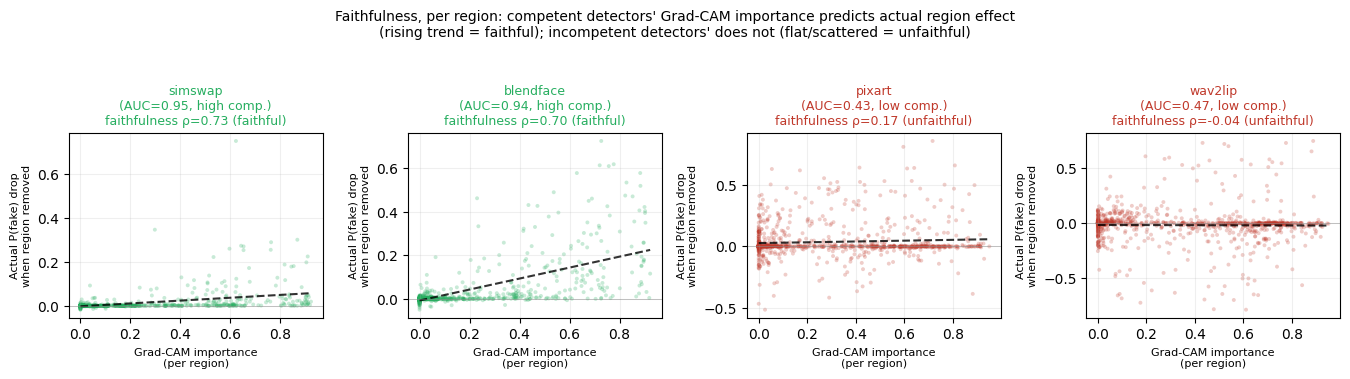

saved /content/drive/MyDrive/CDTS_Research/deepfake-trust-research/figures/gradcam_faithfulness_perregion.png


In [4]:
import pickle, numpy as np, os
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
REPO = "/content/drive/MyDrive/CDTS_Research/deepfake-trust-research"
results=pickle.load(open("/content/fc_results.pkl","rb"))
methods=[m for m in ["simswap","blendface","pixart","wav2lip"] if m in results]

fig,axes=plt.subplots(1,len(methods),figsize=(3.4*len(methods),3.6))
if len(methods)==1: axes=[axes]
for ax,method in zip(axes,methods):
    r=results[method];imp=r['imp'];eff=r['eff']
    color='#27AE60' if r['comp']=='high' else '#C0392B'
    ax.scatter(imp,eff,s=8,alpha=0.25,color=color,edgecolors='none')
    if imp.std()>1e-6:
        b,a=np.polyfit(imp,eff,1);xs=np.linspace(imp.min(),imp.max(),50)
        ax.plot(xs,a+b*xs,'k--',lw=1.5,alpha=0.8)
    rho=r['mean_rho']
    faith="faithful" if rho>0.3 else "unfaithful"
    ax.set_title(f"{method}\n(AUC={r['auc']:.2f}, {r['comp']} comp.)\nfaithfulness ρ={rho:.2f} ({faith})",fontsize=9,color=color)
    ax.set_xlabel("Grad-CAM importance\n(per region)",fontsize=8)
    ax.set_ylabel("Actual P(fake) drop\nwhen region removed",fontsize=8)
    ax.axhline(0,color='gray',lw=0.6,alpha=0.5)
    ax.grid(alpha=0.2)
plt.suptitle("Faithfulness, per region: competent detectors' Grad-CAM importance predicts actual region effect\n(rising trend = faithful); incompetent detectors' does not (flat/scattered = unfaithful)",fontsize=10,y=1.04)
plt.tight_layout()
out=f"{REPO}/figures/gradcam_faithfulness_perregion.png"
plt.savefig(out,dpi=200,bbox_inches='tight');plt.show()
print("saved",out)